![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [30]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [31]:
# Start coding here
# Use as many cells as you need

In [32]:
# 1. Which hour has the highest frequency-of-crimes?
# Extract the first two digits from 'TIME OCC' and convert to integer
crimes = crimes.dropna(subset=["TIME OCC"])

In [33]:
# Convert to string, pad with zeros, and extract hour safely
crimes["hour_occ"] = (
    crimes["TIME OCC"]
    .astype(int)            # Ensure it's treated as a number first
    .astype(str)            # Convert to string to slice it
    .str.zfill(4)           # Pad with leading zeros (e.g., '130' -> '0130')
    .str[:2]                # Take the first two characters
    .astype(int)            # Finally, back to integer
)

# Recalculate peak hour
# Extract the hour and store the peak hour as an integer
crimes["hour_occ"] = crimes["TIME OCC"].astype(str).str.zfill(4).str[:2].astype(int)
peak_crime_hour = crimes["hour_occ"].value_counts().idxmax()
print(peak_crime_hour)

12


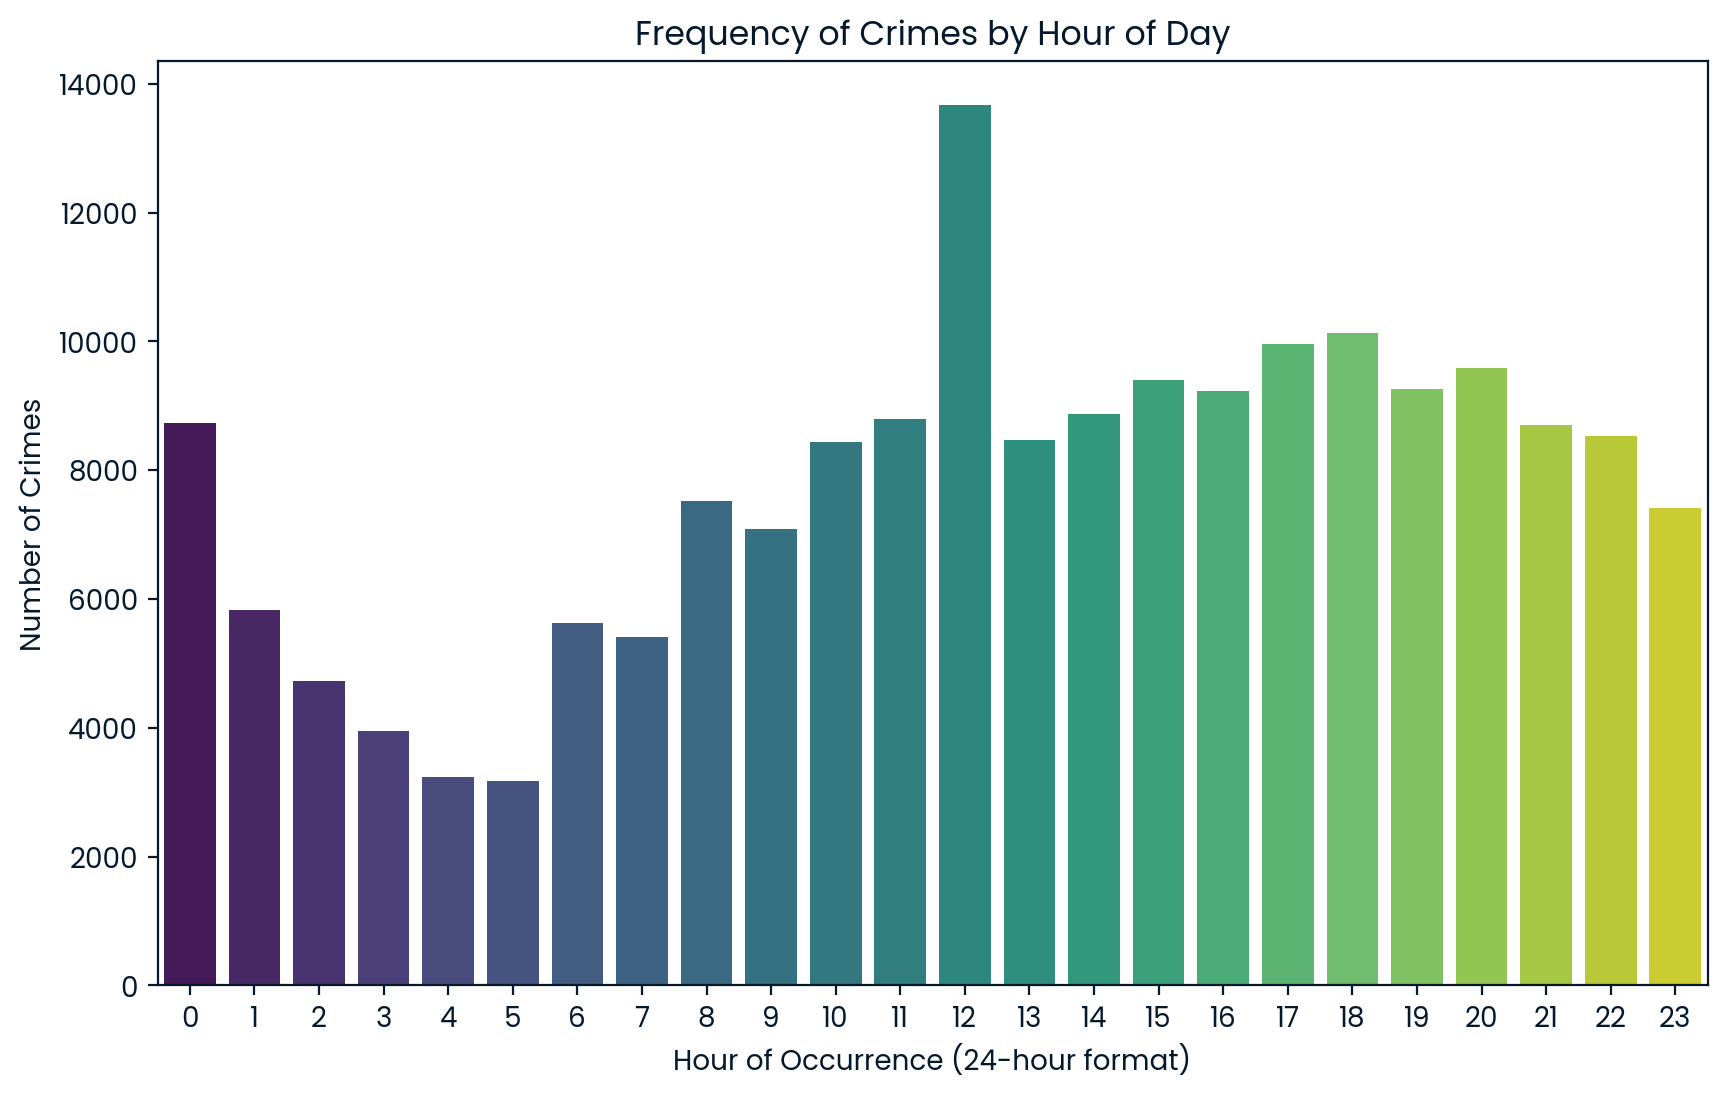

In [34]:
# Create the countplot for crime frequency by hour
plt.figure(figsize=(10, 6))
sns.countplot(data=crimes, x="hour_occ", palette="viridis")

# Add descriptive labels
plt.title("Frequency of Crimes by Hour of Day")
plt.xlabel("Hour of Occurrence (24-hour format)")
plt.ylabel("Number of Crimes")

plt.show()

In [35]:
# 2. Which area has the largest frequency of night crimes?
# Define night hours: 10pm (22:00) to 3:59am (03:00)
night_crimes = crimes[(crimes["hour_occ"] >= 22) | (crimes["hour_occ"] < 4)]
peak_night_crime_location = night_crimes["AREA NAME"].value_counts().idxmax()
print(peak_night_crime_location)

Central


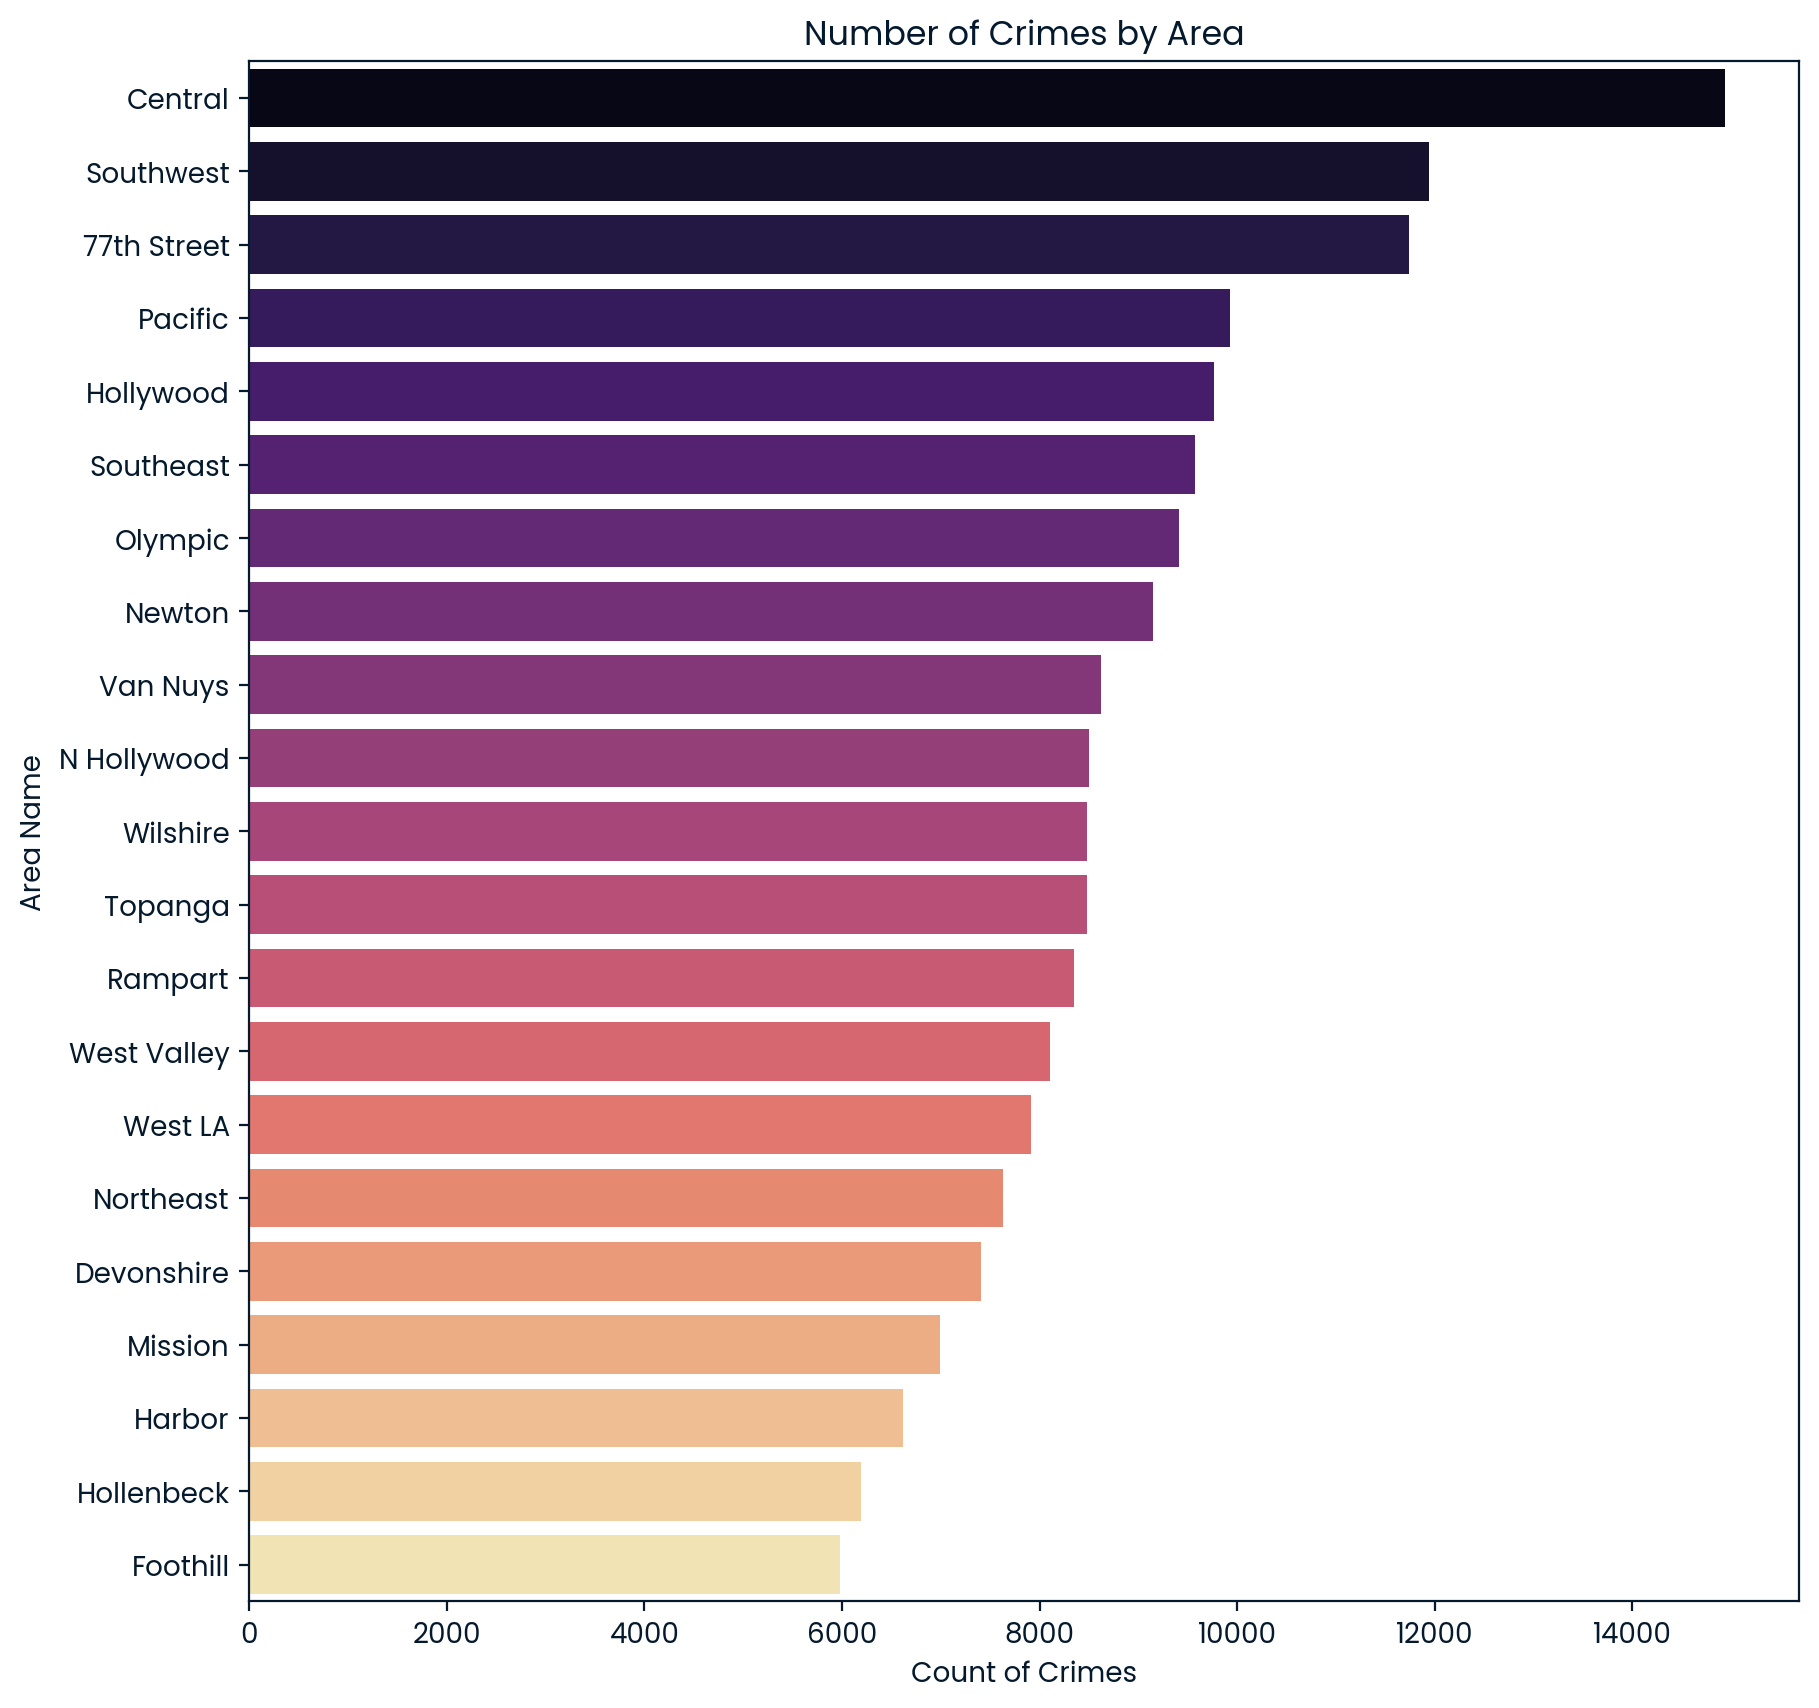

In [36]:
# Counting crime by area
# Set the figure size to accommodate many area names
plt.figure(figsize=(10, 10))

# Create a horizontal countplot
# 'order' ensures the areas are ranked from highest crime frequency to lowest
sns.countplot(
    data=crimes, 
    y="AREA NAME", 
    palette="magma",
    order=crimes["AREA NAME"].value_counts().index
)

# Add titles and labels
plt.title("Number of Crimes by Area")
plt.xlabel("Count of Crimes")
plt.ylabel("Area Name")

plt.show()

In [37]:
# 3. Number of crimes by victim age group
# Define bins and labels for age groups
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]

# Bin the 'Vict Age' column and count frequencies
crimes["age_group"] = pd.cut(crimes["Vict Age"], bins=age_bins, labels=age_labels)
victim_ages = crimes["age_group"].value_counts()

print(f"Peak crime hour: {peak_crime_hour}")
print(f"Peak night crime location: {peak_night_crime_location}")
print(victim_ages)

Peak crime hour: 12
Peak night crime location: Central
26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: age_group, dtype: int64


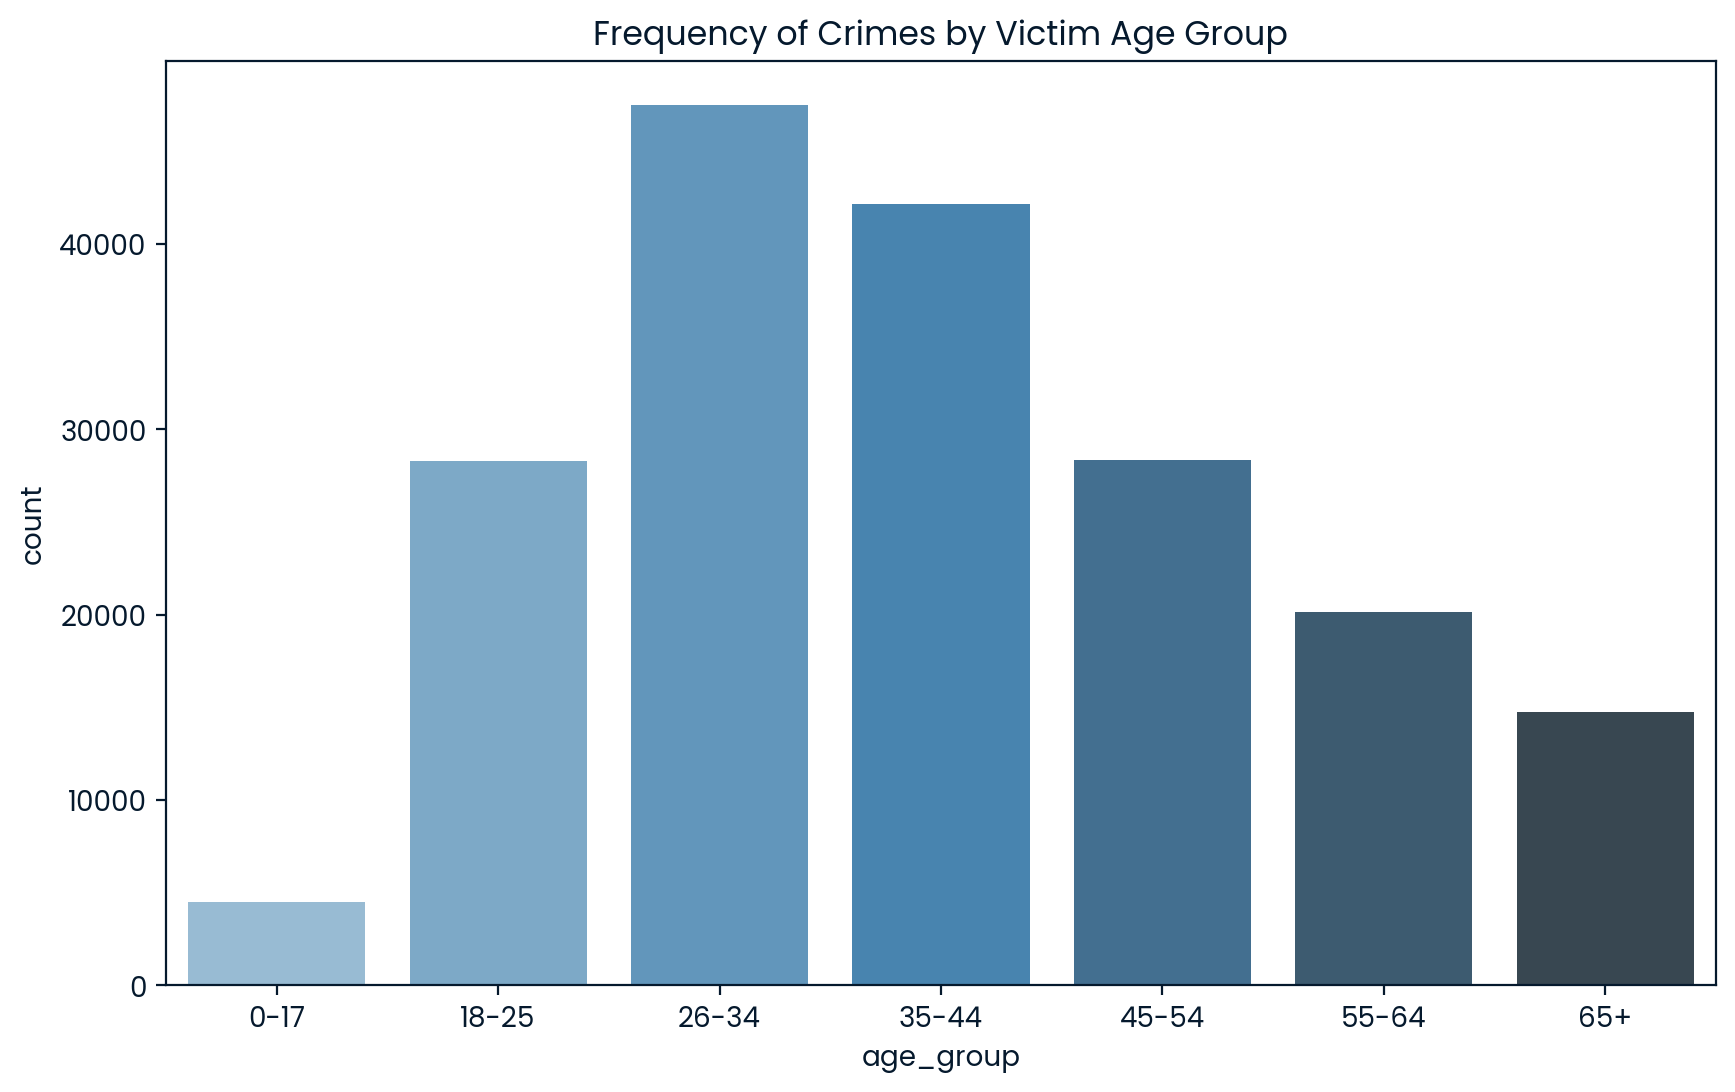

In [38]:
# Counting crimes by victim age group
crimes["age_group"] = pd.cut(crimes["Vict Age"], bins=age_bins, labels=age_labels)

# Count the frequencies
victim_ages = crimes["age_group"].value_counts()

# Visualize with a countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=crimes, x="age_group", palette="Blues_d", order=age_labels)
plt.title("Frequency of Crimes by Victim Age Group")
plt.show()